# ClinVar

In [1]:
import pandas as pd
from pathlib import Path

repo = "https://raw.githubusercontent.com/Joshua-Pillai/NephVar/main/NPHP"

genes = [
    "ANKS6", "CEP164", "CEP290", "GLIS2", "INVS", "IQCB1", "NEK8",
    "NPHP1", "NPHP3", "NPHP4", "RPGRIP1L", "SDCCAG8", "TMEM67",
    "TTC21B", "WDR19", "ZNF423"
]

out = Path("/content/nphp_csv")
out.mkdir(parents=True, exist_ok=True)

total = 0

for g in genes:
    df = pd.read_csv(f"{repo}/{g}.txt", sep="\t", low_memory=False)
    df.to_csv(out / f"{g}.csv", index=False)
    print(f"{g}: {len(df)} variants")
    total += len(df)

print(f"\nTotal: {total:,} variants across {len(genes)} genes")

df = pd.read_csv(out / "ANKS6.csv", low_memory=False)
print(f"ANKS6.csv: {df.shape[0]} rows, {df.shape[1]} columns")
print(df.columns.tolist())

ANKS6: 623 variants
CEP164: 1572 variants
CEP290: 4305 variants
GLIS2: 376 variants
INVS: 1134 variants
IQCB1: 617 variants
NEK8: 488 variants
NPHP1: 1197 variants
NPHP3: 1355 variants
NPHP4: 1841 variants
RPGRIP1L: 2080 variants
SDCCAG8: 903 variants
TMEM67: 1374 variants
TTC21B: 1455 variants
WDR19: 1300 variants
ZNF423: 971 variants

Total: 21,591 variants across 16 genes
ANKS6.csv: 623 rows, 25 columns
['Name', 'Gene(s)', 'Protein change', 'Condition(s)', 'Accession', 'GRCh37Chromosome', 'GRCh37Location', 'GRCh38Chromosome', 'GRCh38Location', 'VariationID', 'AlleleID(s)', 'dbSNP ID', 'Canonical SPDI', 'Variant type', 'Molecular consequence', 'Germline classification', 'Germline date last evaluated', 'Germline review status', 'Somatic clinical impact', 'Somatic clinical impact date last evaluated', 'Somatic clinical impact review status', 'Oncogenicity classification', 'Oncogenicity date last evaluated', 'Oncogenicity review status', 'Unnamed: 24']


In [2]:
import pandas as pd
from pathlib import Path

csv_dir = Path("/content/nphp_csv")

genes = [
    "ANKS6", "CEP164", "CEP290", "GLIS2", "INVS", "IQCB1", "NEK8",
    "NPHP1", "NPHP3", "NPHP4", "RPGRIP1L", "SDCCAG8", "TMEM67",
    "TTC21B", "WDR19", "ZNF423"
]

frames = [
    pd.read_csv(csv_dir / f"{g}.csv", low_memory=False).assign(source=g)
    for g in genes
]

nphp = pd.concat(frames, ignore_index=True)

# Counts
print(f"Total rows:     {len(nphp):>7,}")
print(f"Unique IDs:     {nphp['VariationID'].nunique():>7,}")
print(f"Duplicate rows: {len(nphp) - nphp['VariationID'].nunique():>7,}")

# Across-file duplicates
dup_vids = nphp["VariationID"].value_counts().loc[lambda x: x > 1]
dup_rows = nphp[nphp["VariationID"].isin(dup_vids.index)]

overlap = (
    dup_rows
    .groupby("VariationID")["source"]
    .apply(lambda s: " + ".join(sorted(s.unique())))
)

print(f"\nVariants in >1 file: {len(dup_vids)}")
print("\nOverlap patterns:")
print(overlap.value_counts().to_string())

# Variant types among duplicates
unique_dups = dup_rows.drop_duplicates("VariationID")

print(f"\nVariant types ({len(unique_dups)} unique duplicated variants):")
print(unique_dups["Variant type"].value_counts().to_string())

# Non-CNV duplicates
cnv = {
    "copy number gain",
    "copy number loss",
    "Deletion",
    "Duplication"
}

non_cnv = unique_dups[~unique_dups["Variant type"].isin(cnv)]

if len(non_cnv) > 0:
    print(f"\nNon-CNV duplicates ({len(non_cnv)}):")
    print(
        non_cnv[
            ["VariationID", "Name", "Variant type", "Germline classification"]
        ].to_string(index=False)
    )

# Save report
dup_rows.sort_values(["VariationID", "source"]).to_csv(
    "/content/nphp_duplicate_report.csv",
    index=False
)

Total rows:      21,591
Unique IDs:      21,532
Duplicate rows:      59

Variants in >1 file: 56

Overlap patterns:
source
ANKS6 + INVS                 31
RPGRIP1L + ZNF423            11
IQCB1 + NPHP3                 6
GLIS2 + RPGRIP1L + ZNF423     3
NPHP1 + TTC21B                3
NPHP4 + SDCCAG8               2

Variant types (56 unique duplicated variants):
Variant type
copy number gain    42
copy number loss     7
Deletion             4
Duplication          3


In [3]:
import pandas as pd
from pathlib import Path

csv_dir = Path("/content/nphp_csv")

genes = [
    "ANKS6", "CEP164", "CEP290", "GLIS2", "INVS", "IQCB1", "NEK8",
    "NPHP1", "NPHP3", "NPHP4", "RPGRIP1L", "SDCCAG8", "TMEM67",
    "TTC21B", "WDR19", "ZNF423"
]

# Load and concatenate all NPHP gene files
frames = [
    pd.read_csv(csv_dir / f"{g}.csv", low_memory=False).assign(source=g)
    for g in genes
]

nphp = pd.concat(frames, ignore_index=True)

# Identify VariationIDs appearing in >1 gene file
vid_counts = nphp["VariationID"].value_counts()
dup_vids = vid_counts[vid_counts > 1].index

# Split into two datasets
single_gene = nphp[~nphp["VariationID"].isin(dup_vids)].reset_index(drop=True)

multi_gene = (
    nphp[nphp["VariationID"].isin(dup_vids)]
    .sort_values(["VariationID", "source"])
    .reset_index(drop=True)
)

# For the multi-gene file, collapse to one row per variant with the gene list
multi_gene_collapsed = (
    multi_gene
    .groupby("VariationID")
    .agg({
        "source": lambda s: " + ".join(sorted(s.unique())),
        "Name": "first",
        "Gene(s)": "first",
        "Variant type": "first",
        "Molecular consequence": "first",
        "Germline classification": "first",
        "Germline date last evaluated": "first",
        "Germline review status": "first",
    })
    .rename(columns={"source": "appears_in_gene_files"})
    .reset_index()
)

# Save
single_gene.to_csv("/content/nphp_single_gene.csv", index=False)
multi_gene_collapsed.to_csv("/content/nphp_multi_gene.csv", index=False)

# Report
print(f"Original total rows:        {len(nphp):>7,}")
print(f"Single-gene variants:       {len(single_gene):>7,}  → nphp_single_gene.csv")
print(f"Multi-gene variants:        {len(multi_gene_collapsed):>7,}  → nphp_multi_gene.csv")

print(f"\nReconciliation:")
print(
    f"  {len(single_gene):,} + {len(multi_gene):,} "
    f"(raw multi-gene rows) = {len(single_gene) + len(multi_gene):,}"
)
print(
    f"  {len(single_gene):,} + {len(multi_gene_collapsed):,} "
    f"(unique multi-gene variants) = "
    f"{len(single_gene) + len(multi_gene_collapsed):,} unique variants total"
)

Original total rows:         21,591
Single-gene variants:        21,476  → nphp_single_gene.csv
Multi-gene variants:             56  → nphp_multi_gene.csv

Reconciliation:
  21,476 + 115 (raw multi-gene rows) = 21,591
  21,476 + 56 (unique multi-gene variants) = 21,532 unique variants total


# Variant types

In [4]:
import pandas as pd

df = pd.read_csv("/content/nphp_single_gene.csv", low_memory=False)
print(f"Total variants: {len(df):,}\n")

# Variant type (DNA-level)
print("Variant type distribution:")
vt = df["Variant type"].value_counts(dropna=False)
vt_pct = (vt / len(df) * 100).round(2)
print(pd.DataFrame({"count": vt, "percent": vt_pct}).to_string())

# Molecular consequence (functional effect)
print("\nMolecular consequence (top 15):")
mc = df["Molecular consequence"].value_counts(dropna=False).head(15)
mc_pct = (mc / len(df) * 100).round(2)
print(pd.DataFrame({"count": mc, "percent": mc_pct}).to_string())

# Per-gene variant type breakdown
print("\nVariant type by gene:")
print(pd.crosstab(df["source"], df["Variant type"]).to_string())

Total variants: 21,476

Variant type distribution:
                           count  percent
Variant type                             
single nucleotide variant  18468    85.99
Deletion                    1416     6.59
Duplication                  580     2.70
copy number loss             348     1.62
copy number gain             240     1.12
Microsatellite               228     1.06
Insertion                     95     0.44
Indel                         86     0.40
Inversion                      7     0.03
Haplotype                      5     0.02
Complex                        3     0.01

Molecular consequence (top 15):
                                                                    count  percent
Molecular consequence                                                             
missense variant                                                     5363    24.97
intron variant                                                       4341    20.21
synonymous variant                    

In [9]:
import pandas as pd
df = pd.read_csv("/content/nphp_single_gene.csv", low_memory=False)
print("All unique classification labels:")
print(df["Germline classification"].value_counts(dropna=False).to_string())

All unique classification labels:
Germline classification
Uncertain significance          9455
Likely benign                   7503
Pathogenic                      1854
Likely pathogenic               1075
Benign                           844
Pathogenic/Likely pathogenic     504
Benign/Likely benign             241


In [10]:
df = pd.read_csv("/content/nphp_single_gene.csv", low_memory=False)

missense = df[df["Molecular consequence"].str.contains("missense", case=False, na=False)]

print(f"Total missense variants: {len(missense):,}\n")

# Crosstab: rows = ClinVar label, columns = gene
ct = pd.crosstab(missense["Germline classification"], missense["source"], margins=True, margins_name="Total")
print(ct.to_string())

Total missense variants: 8,484

source                        ANKS6  CEP164  CEP290  GLIS2  INVS  IQCB1  NEK8  NPHP1  NPHP3  NPHP4  RPGRIP1L  SDCCAG8  TMEM67  TTC21B  WDR19  ZNF423  Total
Germline classification                                                                                                                                    
Benign                            5      14       6      2     1      4     0      2      0      7         5        1       2       5      5       2     61
Benign/Likely benign              3       4       4      3     6      1     1      5      3     13         8        2       2       4      3       2     64
Likely benign                     7      14      14      3     1      2     2      7      4      8         4        2       7      10      3       4     92
Likely pathogenic                 2       1       4      0     1      0     0      3      4      3         8        2      29       5      9       1     72
Pathogenic                      

# Variant histories

In [12]:
import pandas as pd
import gzip
import urllib.request
from pathlib import Path

# Load the NPHP variant lists
single_gene = pd.read_csv("/content/nphp_single_gene.csv", low_memory=False)
multi_gene = pd.read_csv("/content/nphp_multi_gene.csv", low_memory=False)

# Use all unique CAKUT VariationIDs as keys
target_ids = set(
    pd.concat([
        single_gene["VariationID"],
        multi_gene["VariationID"]
    ])
    .dropna()
    .astype(str)
)

print(f"Targeting {len(target_ids):,} CAKUT VariationIDs")

# Download submission_summary.txt.gz from NCBI FTP
url = "https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/submission_summary.txt.gz"
local = Path("/content/submission_summary.txt.gz")

if not local.exists():
    print(f"Downloading {url} ...")
    urllib.request.urlretrieve(url, local)
    print(f"  Saved: {local.stat().st_size / 1e6:.1f} MB")
else:
    print(f"Using cached file: {local.stat().st_size / 1e6:.1f} MB")

# Stream-filter: read line-by-line, keep only rows matching CAKUT VariationIDs
matched_rows = []
header_line = None
n_total = 0

with gzip.open(local, "rt", encoding="utf-8") as f:
    for line in f:
        if line.startswith("##"):           # metadata header lines
            continue

        if line.startswith("#"):            # column header
            header_line = line.lstrip("#").strip().split("\t")
            continue

        n_total += 1
        cols = line.rstrip("\n").split("\t")

        # VariationID is the first column
        if cols[0] in target_ids:
            matched_rows.append(cols)

print(f"\nScanned {n_total:,} submission records")
print(f"Matched to CAKUT variants: {len(matched_rows):,}")

# Build dataframe
history = pd.DataFrame(matched_rows, columns=header_line)

# Keep both string and numeric-friendly VariationID handling clean
history["VariationID"] = pd.to_numeric(history["VariationID"], errors="coerce").astype("Int64")

# Save
history.to_csv("/content/nphp_submission_history.csv", index=False)

print(f"\nSaved: /content/nphp_submission_history.csv")
print(
    f"  {len(history):,} submissions across "
    f"{history['VariationID'].nunique():,} variants"
)

# Sanity check: how many nphp variants got at least one submission?
matched_variants = set(history["VariationID"].dropna().astype(str))
unmatched = target_ids - matched_variants

print(f"  Variants with submissions: {len(matched_variants):,} / {len(target_ids):,}")
print(f"  Variants with NO submissions: {len(unmatched):,}")

Targeting 21,532 CAKUT VariationIDs
Using cached file: 382.0 MB

Scanned 6,362,731 submission records
Matched to CAKUT variants: 34,561

Saved: /content/nphp_submission_history.csv
  34,561 submissions across 21,532 variants
  Variants with submissions: 21,532 / 21,532
  Variants with NO submissions: 0


Total submissions: 34,561
Unique variants: 21,532
Mean submissions per variant: 1.61 (95% CI: 1.58–1.63)
Median submissions per variant: 1
Max submissions for a single variant: 37

Distribution of submissions per variant:
1     15708
2      3095
3      1294
4       562
5       328
6       169
7        98
8        60
9        40
10       44
11       32
12       22
13       21
14       17
15       13

Variants with >10 submissions: 134 (0.6%)


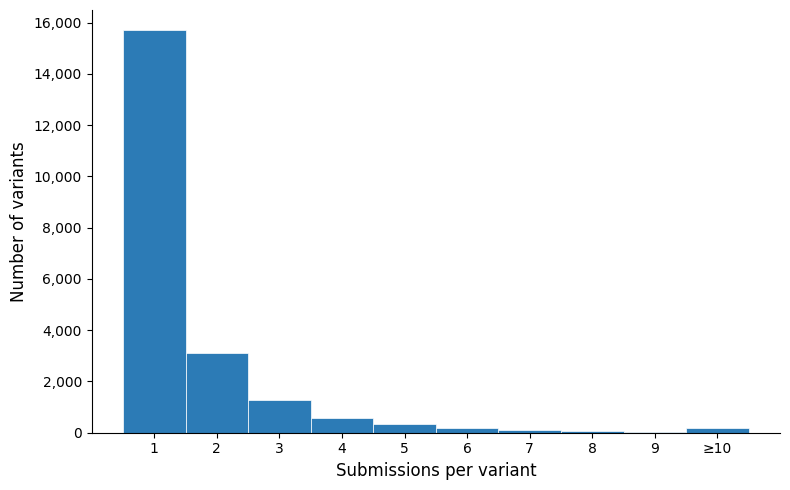

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats

# Load nphp submission history
history = pd.read_csv("/content/nphp_submission_history.csv", low_memory=False)

# Submissions per variant
sub_counts = history.groupby("VariationID").size()

# Summary statistics
n = sub_counts.shape[0]
mean = sub_counts.mean()
median = sub_counts.median()
max_subs = sub_counts.max()

# Mean and 95% CI via t-distribution
se = stats.sem(sub_counts)
ci_low, ci_high = stats.t.interval(0.95, df=n - 1, loc=mean, scale=se)

print(f"Total submissions: {len(history):,}")
print(f"Unique variants: {n:,}")
print(f"Mean submissions per variant: {mean:.2f} (95% CI: {ci_low:.2f}–{ci_high:.2f})")
print(f"Median submissions per variant: {median:.0f}")
print(f"Max submissions for a single variant: {max_subs}")
print()

print("Distribution of submissions per variant:")
print(sub_counts.value_counts().sort_index().head(15).to_string())

over_10 = (sub_counts > 10).sum()
print(f"\nVariants with >10 submissions: {over_10:,} ({over_10 / n * 100:.1f}%)")

# Plot histogram
fig, ax = plt.subplots(figsize=(8, 5))

cap = 10
capped = sub_counts.clip(upper=cap)
bins = np.arange(0.5, cap + 1.5, 1)

ax.hist(capped, bins=bins, color="#2c7bb6", edgecolor="white", linewidth=0.5)

ax.set_xlabel("Submissions per variant", fontsize=12)
ax.set_ylabel("Number of variants", fontsize=12)

ax.set_xticks(range(1, cap + 1))
ax.set_xticklabels([str(i) if i < cap else "≥10" for i in range(1, cap + 1)])

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("/content/nphp_submissions_per_variant.png", dpi=300)
plt.show()

In [14]:
import pandas as pd

history = pd.read_csv("/content/nphp_submission_history.csv", low_memory=False)

history["DateLastEvaluated"] = pd.to_datetime(
    history["DateLastEvaluated"],
    errors="coerce"
)

history["year"] = history["DateLastEvaluated"].dt.year

def bucket(s):
    if pd.isna(s):
        return None

    s = str(s).strip()

    if s == "Pathogenic":
        return "P"
    if s == "Likely pathogenic":
        return "LP"
    if s == "Uncertain significance":
        return "VUS"
    if s == "Likely benign":
        return "LB"
    if s == "Benign":
        return "B"

    return None

history["bucket"] = history["ClinicalSignificance"].apply(bucket)

clean = history.dropna(subset=["VariationID", "DateLastEvaluated", "year", "bucket"]).copy()

# Sort chronologically
clean = clean.sort_values(["VariationID", "DateLastEvaluated"])

years = range(int(clean["year"].min()), int(clean["year"].max()) + 1)

rows = []

for y in years:
    # Keep all submissions up to that year
    up_to_year = clean[clean["year"] <= y]

    # For each variant, keep latest known classification as of that year
    latest = (
        up_to_year
        .sort_values(["VariationID", "DateLastEvaluated"])
        .drop_duplicates("VariationID", keep="last")
    )

    counts = latest["bucket"].value_counts()

    rows.append({
        "year": y,
        "P": counts.get("P", 0),
        "LP": counts.get("LP", 0),
        "VUS": counts.get("VUS", 0),
        "LB": counts.get("LB", 0),
        "B": counts.get("B", 0),
        "total_unique_variants": latest["VariationID"].nunique()
    })

current_by_year = pd.DataFrame(rows).set_index("year")

print("Latest classification as of each year, one category per variant:")
print(current_by_year.to_string())

current_by_year.to_csv("/content/nphp_latest_classification_by_year.csv")
print("\nSaved: /content/nphp_latest_classification_by_year.csv")

Latest classification as of each year, one category per variant:
         P    LP   VUS    LB     B  total_unique_variants
year                                                     
1997     3     0     0     0     0                      3
1998     3     0     0     0     0                      3
1999     3     0     0     0     0                      3
2000     4     0     0     0     0                      4
2001     4     0     0     0     0                      4
2002    12     0     0     0     0                     12
2003    17     0     0     0     0                     17
2004    18     0     0     0     0                     18
2005    21     0     0     0     0                     21
2006    28     0     0     0     0                     28
2007    50     0     0     0     0                     50
2008    56     0     0     0     0                     56
2009    74     0     1     0     3                     78
2010   112     0     1     1    18                    132
2011   

In [15]:
import numpy as np
from scipy import stats
import pandas as pd

# Use the reclassification-adjusted table:
# one latest classification per variant per year
try:
    trend_df = current_by_year.copy()
except NameError:
    trend_df = pd.read_csv(
        "/content/nphp_latest_classification_by_year.csv",
        index_col="year"
    )

# Make sure year is a normal column
trend_df = trend_df.reset_index()

# Standardize year column name if needed
if "index" in trend_df.columns and "year" not in trend_df.columns:
    trend_df = trend_df.rename(columns={"index": "year"})

# Restrict to modern ClinVar era
trend_df = trend_df[trend_df["year"] >= 2013].copy()

x = trend_df["year"].values

print(f"Year range: {trend_df['year'].min()}–{trend_df['year'].max()}\n")

for bucket in ["P", "LP", "VUS", "LB", "B"]:
    if bucket not in trend_df.columns:
        continue

    y = trend_df[bucket].values

    if y.max() == 0:
        continue

    # Linear fit
    slope_lin, intercept_lin, r_lin, _, _ = stats.linregress(x, y)
    r2_lin = r_lin ** 2

    # Exponential fit requires positive values
    mask = y > 0

    if mask.sum() < 3:
        print(f"{bucket}: not enough positive yearly values for exponential fit")
        print()
        continue

    log_y = np.log(y[mask])
    slope_exp, intercept_exp, r_exp, _, _ = stats.linregress(x[mask], log_y)
    r2_exp = r_exp ** 2

    better = "exponential" if r2_exp > r2_lin else "linear"

    growth_pct = (np.exp(slope_exp) - 1) * 100

    if slope_exp > 0:
        doubling = f"{np.log(2) / slope_exp:.3f} yrs"
    else:
        doubling = "not applicable"

    print(f"{bucket} [{better}]:")
    print(
        f"  Linear:      y = {slope_lin:.2f}x + ({intercept_lin:.2f})   "
        f"R² = {r2_lin:.4f}   slope = {slope_lin:+.1f} variants/yr"
    )
    print(
        f"  Exponential: y = e^({slope_exp:.4f}x + ({intercept_exp:.4f}))   "
        f"R² = {r2_exp:.4f}   growth = {growth_pct:+.1f}%/yr   "
        f"doubling = {doubling}"
    )
    print()

Year range: 2013–2026

P [exponential]:
  Linear:      y = 153.74x + (-309428.38)   R² = 0.9360   slope = +153.7 variants/yr
  Exponential: y = e^(0.1639x + (-324.2564))   R² = 0.9883   growth = +17.8%/yr   doubling = 4.229 yrs

LP [exponential]:
  Linear:      y = 107.62x + (-216912.42)   R² = 0.8074   slope = +107.6 variants/yr
  Exponential: y = e^(0.4239x + (-851.1654))   R² = 0.9738   growth = +52.8%/yr   doubling = 1.635 yrs

VUS [exponential]:
  Linear:      y = 817.15x + (-1646842.31)   R² = 0.8828   slope = +817.1 variants/yr
  Exponential: y = e^(0.4544x + (-910.6076))   R² = 0.9426   growth = +57.5%/yr   doubling = 1.525 yrs

LB [exponential]:
  Linear:      y = 616.30x + (-1242333.94)   R² = 0.8212   slope = +616.3 variants/yr
  Exponential: y = e^(0.5924x + (-1190.2362))   R² = 0.9504   growth = +80.8%/yr   doubling = 1.170 yrs

B [linear]:
  Linear:      y = 81.51x + (-164070.29)   R² = 0.9511   slope = +81.5 variants/yr
  Exponential: y = e^(0.2117x + (-421.5027))   R² =

# Reclassification Rates

In [16]:
import pandas as pd

dataset = "nphp"   # change to "cgn" if needed

history = pd.read_csv(f"/content/{dataset}_submission_history.csv", low_memory=False)
history["DateLastEvaluated"] = pd.to_datetime(history["DateLastEvaluated"], errors="coerce")

def bucket(s):
    if pd.isna(s):
        return None

    s = str(s).strip()

    if s == "Pathogenic":
        return "P"
    if s == "Likely pathogenic":
        return "LP"
    if s == "Uncertain significance":
        return "VUS"
    if s == "Likely benign":
        return "LB"
    if s == "Benign":
        return "B"

    if "Pathogenic/Likely pathogenic" in s:
        return "P"
    if "Benign/Likely benign" in s:
        return "B"
    if "Uncertain" in s:
        return "VUS"
    if "Likely pathogenic" in s:
        return "LP"
    if "Likely benign" in s:
        return "LB"
    if "Pathogenic" in s:
        return "P"
    if "Benign" in s:
        return "B"

    return None

history["bucket"] = history["ClinicalSignificance"].apply(bucket)

# Work only with submissions that have both a date and a clean bucket
dated = history.dropna(subset=["VariationID", "DateLastEvaluated", "bucket"]).copy()
dated = dated.sort_values(["VariationID", "DateLastEvaluated"])

# First-ever and most-recent submission per variant
first = dated.drop_duplicates("VariationID", keep="first")
latest = dated.drop_duplicates("VariationID", keep="last")

# Combine first and latest classification
first_latest = (
    first[["VariationID", "DateLastEvaluated", "bucket"]]
    .rename(columns={
        "DateLastEvaluated": "first_date",
        "bucket": "first_bucket"
    })
    .merge(
        latest[["VariationID", "DateLastEvaluated", "bucket"]]
        .rename(columns={
            "DateLastEvaluated": "latest_date",
            "bucket": "latest_bucket"
        }),
        on="VariationID",
        how="inner"
    )
)

# Reclassification = first bucket differs from latest bucket
reclassified = first_latest[
    first_latest["first_bucket"] != first_latest["latest_bucket"]
].copy()

not_reclassified = first_latest[
    first_latest["first_bucket"] == first_latest["latest_bucket"]
].copy()

reclassified["transition"] = (
    reclassified["first_bucket"] + "_to_" + reclassified["latest_bucket"]
)

reclassified["years_to_reclassification"] = (
    reclassified["latest_date"] - reclassified["first_date"]
).dt.days / 365.25

# Report
print(f"Variants with ≥1 dated, clean-bucket submission: {len(first_latest):,}")
print(f"Reclassified first-to-latest:                    {len(reclassified):,}  ({len(reclassified) / len(first_latest) * 100:.1f}%)")
print(f"Not reclassified first-to-latest:                {len(not_reclassified):,}  ({len(not_reclassified) / len(first_latest) * 100:.1f}%)")

print("\nReclassification direction:")
print(reclassified["transition"].value_counts().to_string())

print("\nFirst bucket counts:")
print(first_latest["first_bucket"].value_counts().to_string())

print("\nLatest bucket counts:")
print(first_latest["latest_bucket"].value_counts().to_string())

# Transition matrix
transition_matrix = pd.crosstab(
    first_latest["first_bucket"],
    first_latest["latest_bucket"],
    rownames=["First bucket"],
    colnames=["Latest bucket"]
)

print("\nFirst-to-latest transition matrix:")
print(transition_matrix.to_string())

# Save outputs
reclassified.to_csv(f"/content/{dataset}_all_reclassified_first_to_latest.csv", index=False)
not_reclassified.to_csv(f"/content/{dataset}_not_reclassified_first_to_latest.csv", index=False)
transition_matrix.to_csv(f"/content/{dataset}_first_latest_transition_matrix.csv")

print(f"\nSaved:")
print(f"  /content/{dataset}_all_reclassified_first_to_latest.csv")
print(f"  /content/{dataset}_not_reclassified_first_to_latest.csv")
print(f"  /content/{dataset}_first_latest_transition_matrix.csv")

Variants with ≥1 dated, clean-bucket submission: 21,359
Reclassified first-to-latest:                    686  (3.2%)
Not reclassified first-to-latest:                20,673  (96.8%)

Reclassification direction:
transition
P_to_LP      200
LP_to_P      179
LB_to_B      145
VUS_to_LB     68
LB_to_VUS     48
VUS_to_P      13
B_to_LB       12
LP_to_VUS      7
P_to_VUS       5
VUS_to_LP      4
VUS_to_B       3
P_to_B         2

First bucket counts:
first_bucket
VUS    9462
LB     7599
P      2115
LP     1262
B       921

Latest bucket counts:
latest_bucket
VUS    9434
LB     7486
P      2100
LP     1280
B      1059

First-to-latest transition matrix:
Latest bucket    B    LB    LP     P   VUS
First bucket                              
B              909    12     0     0     0
LB             145  7406     0     0    48
LP               0     0  1076   179     7
P                2     0   200  1908     5
VUS              3    68     4    13  9374

Saved:
  /content/nphp_all_reclassified_firs

In [17]:
import pandas as pd
import numpy as np
from scipy import stats

dataset = "nphp"   # change to "cgn" if needed

# Load submission history
history = pd.read_csv(f"/content/{dataset}_submission_history.csv", low_memory=False)

# Parse dates
history["DateLastEvaluated"] = pd.to_datetime(
    history["DateLastEvaluated"],
    errors="coerce"
)

# Bucket ClinVar classifications into 5 groups
def bucket(s):
    if pd.isna(s):
        return None

    s = str(s).strip()

    if s == "Pathogenic":
        return "P"
    if s == "Likely pathogenic":
        return "LP"
    if s == "Uncertain significance":
        return "VUS"
    if s == "Likely benign":
        return "LB"
    if s == "Benign":
        return "B"

    if "Pathogenic/Likely pathogenic" in s:
        return "P"
    if "Benign/Likely benign" in s:
        return "B"
    if "Uncertain" in s:
        return "VUS"
    if "Likely pathogenic" in s:
        return "LP"
    if "Likely benign" in s:
        return "LB"
    if "Pathogenic" in s:
        return "P"
    if "Benign" in s:
        return "B"

    return None

history["bucket"] = history["ClinicalSignificance"].apply(bucket)

# Keep only dated submissions with clean bucket labels
dated = history.dropna(
    subset=["VariationID", "DateLastEvaluated", "bucket"]
).copy()

dated = dated.sort_values(["VariationID", "DateLastEvaluated"])

# First and latest clean dated classification per variant
first = dated.drop_duplicates("VariationID", keep="first")
latest = dated.drop_duplicates("VariationID", keep="last")

# Merge first and latest
first_latest = (
    first[["VariationID", "DateLastEvaluated", "bucket"]]
    .rename(columns={
        "DateLastEvaluated": "first_date",
        "bucket": "first_bucket"
    })
    .merge(
        latest[["VariationID", "DateLastEvaluated", "bucket"]]
        .rename(columns={
            "DateLastEvaluated": "latest_date",
            "bucket": "latest_bucket"
        }),
        on="VariationID",
        how="inner"
    )
)

# Reclassified variants only: first bucket differs from latest bucket
reclassified = first_latest[
    first_latest["first_bucket"] != first_latest["latest_bucket"]
].copy()

# Time to reclassification
reclassified["years_to_reclassification"] = (
    reclassified["latest_date"] - reclassified["first_date"]
).dt.days / 365.25

# Drop invalid/paradoxical intervals
reclassified = reclassified[
    reclassified["years_to_reclassification"] >= 0
].copy()

# Add transition label
reclassified["transition"] = (
    reclassified["first_bucket"] + "_to_" + reclassified["latest_bucket"]
)

# Mean and 95% CI function
def summarize_time(series):
    series = series.dropna()
    n = len(series)

    if n == 0:
        return pd.Series({
            "n": 0,
            "mean_years": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan
        })

    mean = series.mean()

    if n > 1:
        se = stats.sem(series)
        ci_low, ci_high = stats.t.interval(
            0.95,
            df=n - 1,
            loc=mean,
            scale=se
        )
    else:
        ci_low, ci_high = np.nan, np.nan

    return pd.Series({
        "n": n,
        "mean_years": mean,
        "ci_low": ci_low,
        "ci_high": ci_high
    })

# Five key numbers: time to reclassification by starting category
summary = (
    reclassified
    .groupby("first_bucket")["years_to_reclassification"]
    .apply(summarize_time)
    .unstack()
    .reindex(["B", "LB", "VUS", "LP", "P"])
)

print(f"Total reclassified variants: {len(reclassified):,}")
print("\nMean time to reclassification by starting category:")
print(summary.round(2).to_string())

# Save simple outputs
reclassified.to_csv(
    f"/content/{dataset}_all_reclassified_first_to_latest.csv",
    index=False
)

summary.to_csv(
    f"/content/{dataset}_time_to_reclassification_by_starting_category.csv"
)

print(f"\nSaved:")
print(f"  /content/{dataset}_all_reclassified_first_to_latest.csv")
print(f"  /content/{dataset}_time_to_reclassification_by_starting_category.csv")

Total reclassified variants: 686

Mean time to reclassification by starting category:
                  n  mean_years  ci_low  ci_high
first_bucket                                    
B              12.0        5.46    2.33     8.59
LB            193.0        5.12    4.72     5.51
VUS            88.0        4.01    3.50     4.52
LP            186.0        3.00    2.62     3.38
P             207.0        3.96    3.37     4.54

Saved:
  /content/nphp_all_reclassified_first_to_latest.csv
  /content/nphp_time_to_reclassification_by_starting_category.csv


# NephVar Implementation

In [18]:
import pandas as pd, json, os, shutil, glob, re
from pathlib import Path

# 1) ensure nphp (single-gene master) + history
try: nphp
except NameError:
    nphp = pd.read_csv("/content/nphp_single_gene.csv", low_memory=False)
if "source" not in nphp.columns and "appears_in_gene_files" in nphp.columns:
    nphp = nphp.rename(columns={"appears_in_gene_files": "source"})
try: history
except NameError:
    history = pd.read_csv("/content/nphp_submission_history.csv", low_memory=False)

# 2) master database
history["DateLastEvaluated"] = pd.to_datetime(history["DateLastEvaluated"], format="mixed", errors="coerce")
def bk(s):
    if pd.isna(s): return None
    return {"Pathogenic":"P","Likely pathogenic":"LP","Uncertain significance":"VUS","Benign":"B","Likely benign":"LB"}.get(str(s).strip())
history["bucket"] = history["ClinicalSignificance"].apply(bk)
dd = history.dropna(subset=["DateLastEvaluated","bucket"]).sort_values("DateLastEvaluated")
first  = dd.drop_duplicates("VariationID",keep="first")[["VariationID","bucket","DateLastEvaluated"]].rename(columns={"bucket":"first_class","DateLastEvaluated":"first_date"})
latest = dd.drop_duplicates("VariationID",keep="last")[["VariationID","bucket","DateLastEvaluated"]].rename(columns={"bucket":"latest_class","DateLastEvaluated":"latest_date"})
agg = history.groupby("VariationID").agg(n_submissions=("Submitter","size"), n_submitters=("Submitter","nunique"))
sev = {"P":4,"LP":3,"VUS":2,"LB":1,"B":0}
db = (nphp[["VariationID","source","Name","Protein change","Variant type","Molecular consequence","Germline classification","Germline review status"]].drop_duplicates("VariationID")
      .rename(columns={"source":"gene","Protein change":"protein_change","Variant type":"variant_type","Molecular consequence":"consequence","Germline classification":"current_class","Germline review status":"review_status"}))
db = db.merge(first,on="VariationID",how="left").merge(latest,on="VariationID",how="left").merge(agg,on="VariationID",how="left")
db["reclassified"] = db["first_class"].notna() & (db["first_class"]!=db["latest_class"])
db["direction"] = db.apply(lambda r:"" if not r["reclassified"] else ("toward_pathogenic" if sev.get(r["latest_class"],-1)>sev.get(r["first_class"],-1) else "toward_benign"), axis=1)
db["first_year"] = db["first_date"].dt.year; db["latest_year"] = db["latest_date"].dt.year
for c in ["n_submissions","n_submitters"]: db[c]=db[c].fillna(0).astype(int)
db["first_date"]=db["first_date"].dt.strftime("%Y-%m-%d"); db["latest_date"]=db["latest_date"].dt.strftime("%Y-%m-%d")
db.to_csv("/content/nphp_variant_database.csv", index=False)
db[db["reclassified"]].sort_values(["first_class","latest_class"]).to_csv("/content/nphp_db_reclassified_all.csv", index=False)
db.sort_values("n_submitters", ascending=False).to_csv("/content/nphp_db_by_submitters.csv", index=False)
db[db["current_class"].astype(str).str.contains("Conflicting", na=False)].to_csv("/content/nphp_db_conflicting.csv", index=False)

# 3) ACMG bucket per variant + per-gene counts for landing cards
def acmg_bucket(s):
    if pd.isna(s):
        return "Other"
    tokens = [t.strip().lower() for t in re.split(r'[/;,]', str(s))]
    if "pathogenic" in tokens:        return "P"
    if "benign" in tokens:            return "B"
    if "likely pathogenic" in tokens: return "LP"
    if "likely benign" in tokens:     return "LB"
    if "uncertain significance" in tokens: return "VUS"
    return "Other"

db["acmg_bucket"] = db["current_class"].apply(acmg_bucket)

genes_list = sorted([x for x in db["gene"].unique() if x])

ACMG_ORDER = ["P","LP","VUS","LB","B","Other"]
ACMG_LABELS = {"P":"Pathogenic","LP":"Likely pathogenic","VUS":"Uncertain significance",
               "LB":"Likely benign","B":"Benign","Other":"Other / conflicting"}

panel_counts = {}
for gene in genes_list:
    sub = db[db["gene"]==gene]
    counts = sub["acmg_bucket"].value_counts().to_dict()
    panel_counts[gene] = {b: int(counts.get(b,0)) for b in ACMG_ORDER}
    panel_counts[gene]["total"] = len(sub)

print(f"Total variants: {len(db):,}")
for gene in genes_list:
    pc = panel_counts[gene]
    print(f"  {gene:<8} total={pc['total']:>5}  "
          + "  ".join(f"{b}={pc[b]}" for b in ACMG_ORDER))

# 4) timelines (per-variant submission history)
h = history.copy()
h["date"] = h["DateLastEvaluated"].dt.strftime("%Y-%m-%d").fillna("—")
h = h.sort_values("DateLastEvaluated", na_position="last")
timelines = {int(v):[{"date":r["date"],"sub":str(r["Submitter"]),"sig":str(r["ClinicalSignificance"]),
                       "b":(r["bucket"] if pd.notna(r["bucket"]) else "")} for _,r in g.iterrows()]
             for v,g in h.groupby("VariationID")}

Total variants: 21,532
  ANKS6    total=  623  P=50  LP=16  VUS=324  LB=177  B=56  Other=0
  CEP164   total= 1572  P=107  LP=56  VUS=741  LB=601  B=67  Other=0
  CEP290   total= 4305  P=665  LP=328  VUS=1517  LB=1661  B=134  Other=0
  GLIS2    total=  376  P=35  LP=0  VUS=240  LB=69  B=32  Other=0
  INVS     total= 1103  P=106  LP=38  VUS=497  LB=416  B=46  Other=0
  IQCB1    total=  617  P=79  LP=38  VUS=276  LB=163  B=61  Other=0
  NEK8     total=  488  P=27  LP=21  VUS=296  LB=123  B=21  Other=0
  NPHP1    total= 1197  P=205  LP=71  VUS=428  LB=396  B=97  Other=0
  NPHP3    total= 1349  P=123  LP=52  VUS=689  LB=405  B=80  Other=0
  NPHP4    total= 1841  P=157  LP=69  VUS=947  LB=550  B=118  Other=0
  RPGRIP1L total= 2077  P=246  LP=133  VUS=807  LB=825  B=66  Other=0
  SDCCAG8  total=  901  P=143  LP=52  VUS=425  LB=249  B=32  Other=0
  TMEM67   total= 1374  P=202  LP=88  VUS=501  LB=515  B=68  Other=0
  TTC21B   total= 1452  P=146  LP=52  VUS=653  LB=508  B=93  Other=0
  WDR19    

In [20]:
from pathlib import Path

out_dir = Path("/content/html/NPHP/variants")
out_dir.mkdir(parents=True, exist_ok=True)

ACMG_COLORS = {"P":"var(--P)","LP":"var(--LP)","VUS":"var(--VUS)","LB":"var(--LB)","B":"var(--B)","Other":"var(--faint)"}

cards = ""
for gene in genes_list:
    pc = panel_counts[gene]
    boxes = "".join(
        f'<div class="acmgbox" style="background:{ACMG_COLORS[b]}">'
        f'<span class="acmgcount">{pc[b]}</span><span class="acmglabel">{b}</span></div>'
        for b in ACMG_ORDER
    )
    cards += f"""
    <a class="card" href="{gene}.html">
      <div class="card-head">
        <span class="gname">{gene}</span>
        <span class="gtotal">{pc['total']:,} variants</span>
      </div>
      <div class="acmgrow">{boxes}</div>
      <div class="cta">View variants &rarr;</div>
    </a>"""

html = f"""<!DOCTYPE html>
<html lang="en"><head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>NPHP Variants — NephVar</title>
<link rel="preconnect" href="https://fonts.googleapis.com">
<link href="https://fonts.googleapis.com/css2?family=Syne:wght@400;500;600;700&family=DM+Mono:wght@300;400&family=Instrument+Serif:ital@0;1&display=swap" rel="stylesheet">
<style>
:root{{--serif:'Instrument Serif',Georgia,serif;--sans:'Syne',system-ui,sans-serif;
--mono:'DM Mono',ui-monospace,monospace;--accent:#1f6fa8;--ink:#16202b;
--soft:#5d6b78;--faint:#8a96a3;--line:#e6e9ee;--bg:#fbfaf7;
--P:#c0392b;--LP:#e07b18;--VUS:#7f7f7f;--LB:#7fb3d5;--B:#1f6fa8}}
*{{box-sizing:border-box}}
body{{margin:0;font-family:var(--sans);color:var(--ink);background:var(--bg);-webkit-font-smoothing:antialiased}}
.wrap{{max-width:1240px;margin:0 auto;padding:40px 22px 70px}}
.crumb{{font-family:var(--mono);font-size:11px;letter-spacing:.14em;text-transform:uppercase;color:var(--faint);margin-bottom:16px}}
.crumb a{{color:var(--accent);text-decoration:none}}.crumb a:hover{{text-decoration:underline}}
h1{{font-family:var(--serif);font-weight:400;font-size:40px;margin:0 0 4px}}
h1 em{{font-style:italic;color:var(--accent)}}
.sub{{color:var(--soft);font-size:14px;max-width:680px;line-height:1.6;margin-bottom:40px}}
.grid{{display:grid;grid-template-columns:repeat(auto-fill,minmax(280px,1fr));gap:16px}}
.card{{display:block;text-decoration:none;color:inherit;background:#fff;border:1px solid var(--line);
border-radius:6px;padding:22px;transition:transform .14s ease,box-shadow .14s ease,border-color .14s ease}}
.card:hover{{transform:translateY(-2px);box-shadow:0 12px 28px rgba(20,30,45,.10);border-color:#cdd9e4}}
.card-head{{display:flex;align-items:baseline;justify-content:space-between;margin-bottom:14px}}
.gname{{font-family:var(--serif);font-size:28px}}
.gtotal{{font-family:var(--mono);font-size:11px;color:var(--faint)}}
.acmgrow{{display:flex;gap:5px;margin-bottom:14px}}
.acmgbox{{flex:1;border-radius:4px;color:#fff;padding:6px 4px;text-align:center}}
.acmgcount{{display:block;font-family:var(--mono);font-size:14px;font-weight:400}}
.acmglabel{{display:block;font-family:var(--mono);font-size:9px;letter-spacing:.06em;opacity:.9}}
.cta{{font-family:var(--mono);font-size:12px;color:var(--accent)}}
.legend{{display:flex;flex-wrap:wrap;gap:14px;margin-top:32px;font-family:var(--mono);font-size:10.5px;color:var(--soft)}}
.legend span{{display:inline-flex;align-items:center;gap:6px}}
.dot{{width:9px;height:9px;border-radius:99px;display:inline-block}}
</style></head>
<body><div class="wrap">
<div class="crumb"><a href="../../">NephVar</a> / <a href="../">NPHP</a> / Variants</div>
<h1>NPHP <em>Variants</em></h1>
<div class="sub">ClinVar-derived variant database for the 16 nephronophthisis-related
ciliopathy genes &mdash; {len(db):,} unique variants total. Select a gene to
browse its full variant list with classification history and submission timelines.</div>
<div class="grid">{cards}</div>
<div class="legend">
  <span><span class="dot" style="background:var(--P)"></span>Pathogenic (P)</span>
  <span><span class="dot" style="background:var(--LP)"></span>Likely pathogenic (LP)</span>
  <span><span class="dot" style="background:var(--VUS)"></span>Uncertain significance (VUS)</span>
  <span><span class="dot" style="background:var(--LB)"></span>Likely benign (LB)</span>
  <span><span class="dot" style="background:var(--B)"></span>Benign (B)</span>
  <span><span class="dot" style="background:var(--faint)"></span>Other / conflicting</span>
</div>
</div></body></html>"""

(out_dir / "index.html").write_text(html, encoding="utf-8")
print("Written: NPHP/variants/index.html")

Written: NPHP/variants/index.html


In [21]:
gene_template = """<!DOCTYPE html>
<html lang="en"><head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>{gene} Variants — NephVar NPHP</title>
<link rel="preconnect" href="https://fonts.googleapis.com">
<link href="https://fonts.googleapis.com/css2?family=Syne:wght@400;500;600;700&family=DM+Mono:wght@300;400&family=Instrument+Serif:ital@0;1&display=swap" rel="stylesheet">
<style>
:root{{--serif:'Instrument Serif',Georgia,serif;--sans:'Syne',system-ui,sans-serif;
--mono:'DM Mono',ui-monospace,monospace;--accent:#1f6fa8;--ink:#16202b;
--soft:#5d6b78;--faint:#8a96a3;--line:#e6e9ee;--bg:#fbfaf7;
--P:#c0392b;--LP:#e07b18;--VUS:#7f7f7f;--LB:#7fb3d5;--B:#1f6fa8}}
*{{box-sizing:border-box}}
body{{margin:0;font-family:var(--sans);color:var(--ink);background:var(--bg);-webkit-font-smoothing:antialiased}}
.wrap{{max-width:1240px;margin:0 auto;padding:40px 22px 70px}}
.crumb{{font-family:var(--mono);font-size:11px;letter-spacing:.14em;text-transform:uppercase;color:var(--faint);margin-bottom:16px}}
.crumb a{{color:var(--accent);text-decoration:none}}.crumb a:hover{{text-decoration:underline}}
h1{{font-family:var(--serif);font-weight:400;font-size:40px;margin:0 0 4px}}
h1 em{{font-style:italic;color:var(--accent)}}
.sub{{color:var(--soft);font-size:14px;margin-bottom:24px;line-height:1.6}}
.controls{{display:flex;flex-wrap:wrap;gap:10px;align-items:center;margin-bottom:14px}}
input[type=text],select{{font-family:var(--sans);font-size:13px;padding:9px 12px;border:1px solid var(--line);
border-radius:4px;background:#fff;color:var(--ink)}}
input[type=text]{{flex:1;min-width:220px}}
.chk{{display:flex;align-items:center;gap:6px;font-family:var(--mono);font-size:12px;color:var(--soft);cursor:pointer}}
.count{{font-family:var(--mono);font-size:11px;color:var(--faint);margin-left:auto}}
table{{width:100%;border-collapse:collapse;font-size:13px;background:#fff;border:1px solid var(--line);border-radius:4px;overflow:hidden}}
th{{font-family:var(--mono);text-align:left;padding:11px 12px;background:#f6f5f1;font-weight:400;font-size:10.5px;
letter-spacing:.1em;text-transform:uppercase;color:var(--soft);cursor:pointer;white-space:nowrap}}
th:hover{{color:var(--ink)}}
td{{padding:9px 12px;border-top:1px solid var(--line)}}
tbody tr{{cursor:pointer}}tbody tr:hover td{{background:#f7f9fb}}
.mono{{font-family:var(--mono);font-size:11.5px}}
.pill{{font-family:var(--mono);display:inline-block;padding:2px 8px;border-radius:99px;font-size:10px;color:#fff}}
.arrow{{color:var(--faint);margin:0 4px}}
.flag{{font-family:var(--mono);font-size:10px;padding:1px 7px;border-radius:4px;background:#f0f3f6;color:var(--soft)}}
.flag.recl{{background:#fff3e0;color:#b25e00}}
.empty{{padding:40px;text-align:center;color:var(--faint)}}
.ovl{{position:fixed;inset:0;background:rgba(20,30,45,.45);display:none;align-items:flex-start;
justify-content:center;padding:40px 16px;overflow:auto;z-index:10}}
.modal{{background:#fff;border-radius:6px;max-width:680px;width:100%;padding:24px;box-shadow:0 20px 60px rgba(20,30,45,.3)}}
.modal h2{{font-family:var(--serif);margin:0 0 2px;font-size:24px}}
.modal .vid{{font-family:var(--mono);font-size:12px;color:var(--soft);margin-bottom:16px}}
.modal .vid a{{color:var(--accent);text-decoration:none}}.modal .vid a:hover{{text-decoration:underline}}
.grid{{display:grid;grid-template-columns:1fr 1fr;gap:8px 20px;font-size:13px;margin-bottom:18px}}
.grid div span{{color:var(--faint);display:block;font-family:var(--mono);font-size:10px;text-transform:uppercase;letter-spacing:.06em}}
.tl{{border-top:1px solid var(--line);padding-top:12px}}
.tl h3{{font-family:var(--mono);font-size:11px;text-transform:uppercase;letter-spacing:.08em;color:var(--soft);margin:0 0 8px}}
.tlrow{{display:grid;grid-template-columns:90px auto 1fr;gap:10px;align-items:center;padding:6px 0;
border-bottom:1px solid #f0f3f6;font-size:12.5px}}
.tlrow .d{{color:var(--faint);font-family:var(--mono)}}.tlrow .s{{color:var(--soft)}}
.x{{float:right;cursor:pointer;color:var(--faint);font-size:20px;line-height:1}}
</style></head>
<body><div class="wrap">
<div class="crumb"><a href="../../../">NephVar</a> / <a href="../../">NPHP</a> / <a href="../">Variants</a> / {gene}</div>
<h1>{gene} <em>Variants</em></h1>
<div class="sub">{n_total:,} unique ClinVar variants &middot; click any row for full classification
history and submission timeline.</div>

<div class="controls">
  <input id="q" type="text" placeholder="Search variant, protein change, or Variation ID…">
  <select id="cls"><option value="">All current classes</option>
    <option>Pathogenic</option><option>Likely pathogenic</option><option>Uncertain significance</option>
    <option>Likely benign</option><option>Benign</option><option>Conflicting</option>
  </select>
  <label class="chk"><input type="checkbox" id="recl"> Reclassified only</label>
  <span class="count" id="count"></span>
</div>
<table><thead><tr>
  <th data-k="VariationID">Var ID</th>
  <th data-k="protein_change">Protein change</th>
  <th data-k="first_class">First &rarr; Latest</th>
  <th data-k="current_class">Current</th>
  <th data-k="n_submitters">Submitters</th>
  <th data-k="n_submissions">Subs</th>
  <th data-k="first_year">First yr</th>
</tr></thead><tbody id="rows"></tbody></table>
<div id="empty" class="empty" style="display:none">No variants match your search.</div>
</div>
<div class="ovl" id="ovl"><div class="modal" id="modal"></div></div>
<script>
const DATA={data_json}, TL={tl_json};
const C={{P:'var(--P)',LP:'var(--LP)',VUS:'var(--VUS)',LB:'var(--LB)',B:'var(--B)'}};
const BK={{Pathogenic:'P','Likely pathogenic':'LP','Uncertain significance':'VUS','Likely benign':'LB',Benign:'B'}};
const pill=c=>c?`<span class="pill" style="background:${{C[c]||'#9aa6b2'}}">${{c}}</span>`:'';
let sortK='n_submitters',sortDir=-1;
function g(i){{return document.getElementById(i)}}
const q=g('q'),cls=g('cls'),recl=g('recl');
function isR(d){{return d.reclassified===true||d.reclassified==='True'}}
function render(){{
  let r=DATA.filter(d=>{{
    const t=(q.value||'').toLowerCase();
    const hit=!t||[d.Name,d.protein_change,d.VariationID].join(' ').toLowerCase().includes(t);
    return hit&&(!cls.value||String(d.current_class).includes(cls.value))&&(!recl.checked||isR(d));
  }});
  r.sort((a,b)=>{{let x=a[sortK],y=b[sortK];if(x!==''&&!isNaN(x)){{x=+x;y=+y}}return x>y?sortDir:x<y?-sortDir:0}});
  g('count').textContent=`${{r.length.toLocaleString()}} of ${{DATA.length.toLocaleString()}} variants`;
  g('empty').style.display=r.length?'none':'block';
  g('rows').innerHTML=r.map(d=>{{
    const t=d.first_class?(d.first_class===d.latest_class?pill(d.first_class):pill(d.first_class)+'<span class=arrow>&rarr;</span>'+pill(d.latest_class)):'<span style=color:#bcc6d0>&mdash;</span>';
    const fl=isR(d)?' <span class="flag recl">reclassified</span>':'';
    const cur=pill(BK[d.current_class])||'<span class=flag>'+(String(d.current_class).includes('Conflict')?'Conflicting':(d.current_class||'&mdash;'))+'</span>';
    return `<tr data-id="${{d.VariationID}}"><td class=mono>${{d.VariationID}}</td><td class=mono>${{d.protein_change||d.Name}}</td><td>${{t}}${{fl}}</td><td>${{cur}}</td><td class=mono>${{d.n_submitters}}</td><td class=mono>${{d.n_submissions}}</td><td class=mono>${{d.first_year||''}}</td></tr>`;
  }}).join('');
  document.querySelectorAll('#rows tr').forEach(tr=>tr.onclick=()=>openV(tr.dataset.id));
}}
function openV(id){{
  const d=DATA.find(x=>String(x.VariationID)===String(id));
  const tl=TL[id]||[];
  const meta=[['Variant type',d.variant_type],['Consequence',d.consequence],['Current class',d.current_class],
    ['Review status',d.review_status],['First &rarr; latest',(d.first_class||'&mdash;')+' &rarr; '+(d.latest_class||'&mdash;')],
    ['Reclassified',isR(d)?'yes':'no'],
    ['Submitters',d.n_submitters],['Submissions',d.n_submissions]];
  g('modal').innerHTML=`<span class=x onclick="closeV()">&times;</span>
    <h2>{gene} &middot; <span class=mono>${{d.protein_change||d.Name}}</span></h2>
    <div class=vid>Variation ID <a href="https://www.ncbi.nlm.nih.gov/clinvar/variation/${{d.VariationID}}/" target=_blank>${{d.VariationID}} &#8599;</a></div>
    <div class=grid>${{meta.map(m=>`<div><span>${{m[0]}}</span>${{m[1]||'&mdash;'}}</div>`).join('')}}</div>
    <div class=tl><h3>Submission timeline (${{tl.length}})</h3>${{tl.map(s=>`<div class=tlrow><span class=d>${{s.date}}</span><span>${{pill(s.b)||'<span class=flag>'+s.sig+'</span>'}}</span><span class=s>${{s.sub}}</span></div>`).join('')}}</div>`;
  g('ovl').style.display='flex';
}}
function closeV(){{g('ovl').style.display='none'}}
g('ovl').onclick=e=>{{if(e.target.id==='ovl')closeV()}};
document.addEventListener('keydown',e=>{{if(e.key==='Escape')closeV()}});
document.querySelectorAll('th').forEach(th=>th.onclick=()=>{{
  const k=th.dataset.k;if(sortK===k)sortDir*=-1;else{{sortK=k;sortDir=-1}}render();
}});
[q,cls,recl].forEach(el=>el.addEventListener('input',render));
render();
</script></body></html>"""

for gene in genes_list:
    gene_db = db[db["gene"] == gene]
    gene_records = gene_db.fillna("").to_dict(orient="records")
    gene_var_ids = set(gene_db["VariationID"].astype(int))
    gene_tl = {k: v for k, v in timelines.items() if k in gene_var_ids}

    html = gene_template.format(
        gene=gene,
        n_total=len(gene_db),
        data_json=json.dumps(gene_records),
        tl_json=json.dumps(gene_tl),
    )
    (out_dir / f"{gene}.html").write_text(html, encoding="utf-8")
    print(f"{gene:<8} {len(gene_records):>5} variants → {gene}.html")

ANKS6      623 variants → ANKS6.html
CEP164    1572 variants → CEP164.html
CEP290    4305 variants → CEP290.html
GLIS2      376 variants → GLIS2.html
INVS      1103 variants → INVS.html
IQCB1      617 variants → IQCB1.html
NEK8       488 variants → NEK8.html
NPHP1     1197 variants → NPHP1.html
NPHP3     1349 variants → NPHP3.html
NPHP4     1841 variants → NPHP4.html
RPGRIP1L  2077 variants → RPGRIP1L.html
SDCCAG8    901 variants → SDCCAG8.html
TMEM67    1374 variants → TMEM67.html
TTC21B    1452 variants → TTC21B.html
WDR19     1300 variants → WDR19.html
ZNF423     957 variants → ZNF423.html


In [22]:
import zipfile

zip_path = Path("/content/nphp_variants.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for f in sorted(out_dir.glob("*.html")):
        zf.write(f, arcname=f"variants/{f.name}")
    for f in glob.glob("/content/nphp_*.csv") + glob.glob("/content/nphp_db_*.csv"):
        zf.write(f, arcname=f"data/{Path(f).name}")

print(f"{zip_path.name}: {sum(1 for _ in out_dir.glob('*.html'))} HTML pages "
      f"({zip_path.stat().st_size/1024:.1f} KB)")

from google.colab import files
files.download(str(zip_path))

/usr/lib/python3.12/zipfile/__init__.py:1624: UserWarning: Duplicate name: 'data/nphp_db_by_submitters.csv'
  return self._open_to_write(zinfo, force_zip64=force_zip64)


nphp_variants.zip: 17 HTML pages (6384.5 KB)


/usr/lib/python3.12/zipfile/__init__.py:1624: UserWarning: Duplicate name: 'data/nphp_db_reclassified_all.csv'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/usr/lib/python3.12/zipfile/__init__.py:1624: UserWarning: Duplicate name: 'data/nphp_db_conflicting.csv'
  return self._open_to_write(zinfo, force_zip64=force_zip64)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>